<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/05_U_Net_Modeling_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Data Fetching

##Dataset

In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class CTDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.files = sorted(os.listdir(img_dir))  # ensure alignment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img = np.load(os.path.join(self.img_dir, fname))   # shape: (H, W) or (C, H, W)
        mask = np.load(os.path.join(self.mask_dir, fname)) # shape: (H, W)

        # Convert to torch
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        # Ensure channel dimension
        if img.ndim == 2:
            img = img.unsqueeze(0)   # (1, H, W)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0) # (1, H, W)

        return img, mask

##Test

In [3]:
dataset = CTDataset(
    img_dir="/content/drive/MyDrive/brain_ct_project/brain_ct_windowed_3ch/train/images",
    mask_dir="/content/drive/MyDrive/brain_ct_project/brain_ct_windowed_3ch/train/masks"
)

img, mask = dataset[0]

print(img.shape)   # expect: (C, H, W)
print(mask.shape)  # expect: (1, H, W)

torch.Size([3, 256, 256])
torch.Size([1, 256, 256])


#Sampling

##Balanced Patch Dataset

In [4]:
import random

class BalancedPatchDataset(Dataset):
    def __init__(self, base_dataset, patch_size=128):
        self.base_dataset = base_dataset
        self.patch_size = patch_size

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, mask = self.base_dataset[idx]

        _, H, W = img.shape
        ps = self.patch_size

        # Randomly choose positive or negative
        want_positive = random.random() > 0.5

        for _ in range(10):  # try multiple times
            y = random.randint(0, H - ps)
            x = random.randint(0, W - ps)

            img_patch = img[:, y:y+ps, x:x+ps]
            mask_patch = mask[:, y:y+ps, x:x+ps]

            if want_positive:
                if mask_patch.sum() > 0:
                    return img_patch, mask_patch
            else:
                if mask_patch.sum() == 0:
                    return img_patch, mask_patch

        # fallback (if not found)
        return img_patch, mask_patch

##Test

In [5]:
patch_dataset = BalancedPatchDataset(dataset, patch_size=128)

img_p, mask_p = patch_dataset[0]

print(img_p.shape)   # (3, 128, 128)
print(mask_p.shape)  # (1, 128, 128)
print(mask_p.sum())  # >0 means hemorrhage

torch.Size([3, 128, 128])
torch.Size([1, 128, 128])
tensor(0.)


In [6]:
for i in range(20):
    _, m = patch_dataset[i]
    print(m.sum().item())

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
276.0
0.0
556.0
1978.0
0.0
2480.0
0.0
0.0
0.0
1810.0


#Batching

##DataLoader

In [26]:
from torch.utils.data import DataLoader

loader = DataLoader(
    patch_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,   # if Colab → can be 2, local → maybe 0
    pin_memory=True
)

##Test

In [27]:
imgs, masks = next(iter(loader))

print(imgs.shape)   # (B, 3, 128, 128)
print(masks.shape)  # (B, 1, 128, 128)

torch.Size([16, 3, 128, 128])
torch.Size([16, 1, 128, 128])


#Forward Pass (U-Net)

##Simple U-Net

In [28]:
import torch.nn as nn
import torch

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def C(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = C(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = C(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = C(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = C(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = C(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = C(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = C(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)  # logits

##Run forward pass

In [29]:
model = UNet()

outputs = model(imgs)

print(outputs.shape)

torch.Size([16, 1, 128, 128])


#Loss Function (Dice + BCEWithLogits)

##Dice Loss

In [30]:
import torch

def dice_loss(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)

    intersection = (probs * targets).sum(dim=(1,2,3))
    union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - dice.mean()

##Combined Loss

In [31]:
bce_loss = torch.nn.BCEWithLogitsLoss()

def combined_loss(logits, targets):
    d = dice_loss(logits, targets)
    b = bce_loss(logits, targets)
    return 0.7 * d + 0.3 * b

##Test Loss

In [32]:
loss = combined_loss(outputs, masks)

print(loss.item())

0.882527232170105


#Backward + Optimizer

##Optimizer

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

##One Training Step

In [34]:
optimizer.zero_grad()     # reset gradients

loss.backward()           # compute gradients

optimizer.step()          # update weights

#Training Loop (Epoch-based)

##Training Loop

In [35]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMPORTANT: create model and move to device FIRST
model = UNet().to(device)

# THEN create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for imgs, masks in loader:

        imgs = imgs.to(device)
        masks = masks.to(device)

        # Forward
        outputs = model(imgs)

        # Loss
        loss = combined_loss(outputs, masks)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/15 - Loss: 0.7180
Epoch 2/15 - Loss: 0.7028
Epoch 3/15 - Loss: 0.7027
Epoch 4/15 - Loss: 0.7432
Epoch 5/15 - Loss: 0.7054
Epoch 6/15 - Loss: 0.7026
Epoch 7/15 - Loss: 0.7033
Epoch 8/15 - Loss: 0.7025
Epoch 9/15 - Loss: 0.7031
Epoch 10/15 - Loss: 0.7025
Epoch 11/15 - Loss: 0.7020
Epoch 12/15 - Loss: 0.7035
Epoch 13/15 - Loss: 0.7048
Epoch 14/15 - Loss: 0.7023
Epoch 15/15 - Loss: 0.7022


##Verify predictions

In [36]:
with torch.no_grad():
    preds = torch.sigmoid(outputs)

print(preds.min().item(), preds.max().item())

8.505628146249222e-11 0.3606024980545044


##Check mask vs prediction visually

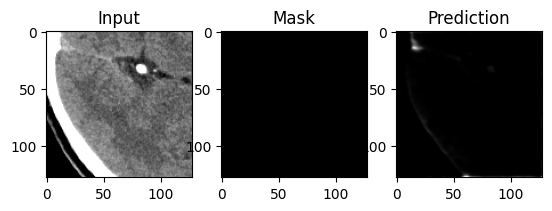

In [39]:
import matplotlib.pyplot as plt

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(imgs[0][0].cpu(), cmap="gray")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(masks[0][0].cpu(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(preds[0][0].cpu(), cmap="gray")

plt.show()